In [1]:
!pip install numpy pandas scikit-learn tensorflow

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/8.9 MB 3.6 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.9 MB 3.6 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/8.9 MB 3.9 MB/s eta 0:00:02
   ---------------- ----------------------- 3.7/8.9 MB 4.1 MB/s eta 0:00:02
   --------------------- ------------------ 4.7/8.9 MB 4.3 MB/s eta 0:00:01
   ------------------------- -------------- 5.8/8.9 MB 4.3 MB/s eta 0:00:01
   ------------------------------ --------- 6.8/8.9 MB 4.5 MB/s eta 0:00:01
   --------------------------------- ------ 7.3/8.9 MB 4.5 MB/s eta 0:00:01
   -------------------------------------- - 8.7/8.9 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 8.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.56.0 requires protobuf<8,>=3.20, but you have protobuf 3.19.6 which is incompatible.


In [21]:
!pip install matplotlib

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [23]:
data = pd.read_csv('C:/Users/ADMIN/Downloads/housing/HousingData.csv')

data.isnull().sum()

data = data.fillna(data.mean())

In [24]:
# 2. Split features and target
X = data.drop("MEDV", axis=1)
y = data["MEDV"]

In [25]:
# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# 4. Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# 5. Build Deep Neural Network
model = Sequential()

# Input layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output layer
model.add(Dense(1))

In [28]:
# 6.Compile Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 7. Train model
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)



Epoch 1/50
26/26 [==============================] - 1s 2ms/step - loss: 570.5114 - mae: 21.9117
Epoch 2/50
26/26 [==============================] - 0s 2ms/step - loss: 472.3109 - mae: 19.4984
Epoch 3/50
26/26 [==============================] - 0s 2ms/step - loss: 311.3280 - mae: 15.2696
Epoch 4/50
26/26 [==============================] - 0s 2ms/step - loss: 134.5535 - mae: 9.1806
Epoch 5/50
26/26 [==============================] - 0s 2ms/step - loss: 64.6824 - mae: 6.1722
Epoch 6/50
26/26 [==============================] - 0s 2ms/step - loss: 40.7471 - mae: 4.7911
Epoch 7/50
26/26 [==============================] - 0s 2ms/step - loss: 30.2479 - mae: 4.0303
Epoch 8/50
26/26 [==============================] - 0s 2ms/step - loss: 26.3645 - mae: 3.7783
Epoch 9/50
26/26 [==============================] - 0s 3ms/step - loss: 23.8864 - mae: 3.5572
Epoch 10/50
26/26 [==============================] - 0s 5ms/step - loss: 22.1928 - mae: 3.4488
Epoch 11/50
26/26 [==============================] -

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------- LINEAR REGRESSION ----------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)

# ---------------- DNN ----------------
dnn_pred = model.predict(X_test).flatten()

dnn_mse = mean_squared_error(y_test, dnn_pred)
dnn_mae = mean_absolute_error(y_test, dnn_pred)

# ---------------- PRINT RESULTS ----------------
print("===== MODEL COMPARISON =====\n")

print("Linear Regression:")
print("MSE:", lr_mse)
print("MAE:", lr_mae)

print("\nDeep Neural Network:")
print("MSE:", dnn_mse)
print("MAE:", dnn_mae)

4/4 [==============================] - 0s 3ms/step
===== MODEL COMPARISON =====

Linear Regression:
MSE: 25.017672023842874
MAE: 3.149923357345804

Deep Neural Network:
MSE: 13.35920797553374
MAE: 2.3939036762013153


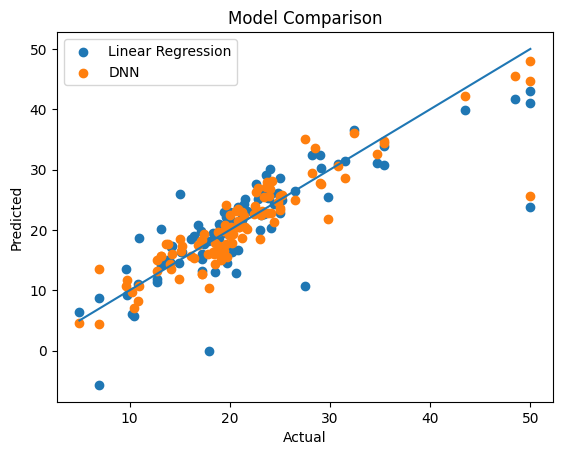

In [30]:
import matplotlib.pyplot as plt


plt.scatter(y_test, lr_pred, label='Linear Regression')
plt.scatter(y_test, dnn_pred, label='DNN')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

In [19]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 3.4 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.2 MB 5.6 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 7.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 8.8 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 9.4 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 27.5 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 

In [ ]:
# Read [](file:///c%3A/Users/ADMIN/OneDrive/Desktop/dl/DL_boston.ipynb)

# ## Line-by-line Explanation for DL_boston.ipynb

# ### Cell 1
# `!pip install numpy pandas scikit-learn tensorflow`
# - Runs a shell command from the notebook to install packages needed for data processing and deep learning.

# ### Cell 2
# `!pip install matplotlib`
# - Installs `matplotlib`, a plotting library for visualizing results.

# ### Cell 3
# `import pandas as pd`
# - Imports pandas and assigns it the alias `pd`, used for reading and manipulating tabular data.

# `import numpy as np`
# - Imports NumPy as `np`, used for numerical array operations.

# `from sklearn.model_selection import train_test_split`
# - Imports `train_test_split` to divide the dataset into training and test sets.

# `from sklearn.preprocessing import StandardScaler`
# - Imports `StandardScaler` to normalize features to zero mean and unit variance.

# `from tensorflow.keras.models import Sequential`
# - Imports the Keras `Sequential` model container for building a layered neural network.

# `from tensorflow.keras.layers import Dense, Input`
# - Imports the `Dense` fully connected layer and the `Input` layer to define the network input shape.

# ---

# ### Cell 4
# `data = pd.read_csv('C:/Users/ADMIN/Downloads/housing/HousingData.csv')`
# - Reads the Boston housing CSV file into a pandas DataFrame called `data`.

# `data.isnull().sum()`
# - Checks how many missing values exist in each column. It helps identify incomplete data.

# `data = data.fillna(data.mean())`
# - Fills missing values with the mean of each column so the model can train without NaNs.

# ---

# ### Cell 5
# `X = data.drop("MEDV", axis=1)`
# - Creates feature matrix `X` by removing the target column `MEDV` from the dataset.

# `y = data["MEDV"]`
# - Sets target vector `y` to the median house value column `MEDV`.

# ---

# ### Cell 6
# `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`
# - Splits data into training and test sets:
#   - `test_size=0.2` means 20% is reserved for testing.
#   - `random_state=42` ensures the split is reproducible.

# ---

# ### Cell 7
# `scaler = StandardScaler()`
# - Creates a scaler object to standardize numeric features.

# `X_train = scaler.fit_transform(X_train)`
# - Learns scaling parameters from training features and applies the transformation to `X_train`.

# `X_test = scaler.transform(X_test)`
# - Applies the same scaling to `X_test` using parameters learned from the training data.

# ---

# ### Cell 8
# `model = Sequential()`
# - Creates an empty sequential neural network model.

# `model.add(Input(shape=(X_train.shape[1],)))`
# - Adds an input layer specifying the number of features in `X_train`.

# `model.add(Dense(64, activation='relu'))`
# - Adds a hidden layer with 64 neurons and ReLU activation to learn nonlinear patterns.

# `model.add(Dense(32, activation='relu'))`
# - Adds a second hidden layer with 32 neurons and ReLU activation for additional modeling capacity.

# `model.add(Dense(1))`
# - Adds the output layer with one neuron to predict the target house price.

# ---

# ### Cell 9
# `model.compile(optimizer='adam', loss='mse', metrics=['mae'])`
# - Configures the model for training:
#   - `optimizer='adam'` uses Adam gradient descent.
#   - `loss='mse'` uses mean squared error for regression.
#   - `metrics=['mae']` tracks mean absolute error during training.

# `model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)`
# - Trains the model on the training data:
#   - `epochs=50` runs 50 full passes over the dataset.
#   - `batch_size=16` updates weights after 16 samples.
#   - `verbose=1` prints progress for each epoch.

# ---

# ### Cell 10
# `from sklearn.linear_model import LinearRegression`
# - Imports linear regression for a baseline comparison model.

# `from sklearn.metrics import mean_squared_error, mean_absolute_error`
# - Imports regression metrics for model evaluation.

# `lr_model = LinearRegression()`
# - Creates a linear regression model instance.

# `lr_model.fit(X_train, y_train)`
# - Trains the linear regression model on the same training data.

# `lr_pred = lr_model.predict(X_test)`
# - Uses the trained linear model to predict house prices for the test set.

# `lr_mse = mean_squared_error(y_test, lr_pred)`
# - Computes the mean squared error of linear regression predictions.

# `lr_mae = mean_absolute_error(y_test, lr_pred)`
# - Computes the mean absolute error of linear regression predictions.

# `dnn_pred = model.predict(X_test).flatten()`
# - Uses the neural network to predict prices for the test set and flattens the result into a 1D array.

# `dnn_mse = mean_squared_error(y_test, dnn_pred)`
# - Computes mean squared error for the deep neural network predictions.

# `dnn_mae = mean_absolute_error(y_test, dnn_pred)`
# - Computes mean absolute error for the deep neural network predictions.

# `print("===== MODEL COMPARISON =====\n")`
# - Prints a header for the comparison output.

# `print("Linear Regression:")`
# - Prints the name of the first model.

# `print("MSE:", lr_mse)`
# - Prints the linear regression MSE.

# `print("MAE:", lr_mae)`
# - Prints the linear regression MAE.

# `print("\nDeep Neural Network:")`
# - Prints the DNN section header.

# `print("MSE:", dnn_mse)`
# - Prints the DNN MSE.

# `print("MAE:", dnn_mae)`
# - Prints the DNN MAE.

# ---

# ### Cell 11
# `import matplotlib.pyplot as plt`
# - Imports the plotting library for visualization.

# `plt.scatter(y_test, lr_pred, label='Linear Regression')`
# - Creates a scatter plot of actual vs predicted values for linear regression.

# `plt.scatter(y_test, dnn_pred, label='DNN')`
# - Adds a scatter plot of actual vs predicted values for the DNN.

# `plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])`
# - Draws a diagonal reference line representing perfect prediction.

# `plt.legend()`
# - Shows the legend to label each model’s points.

# `plt.title("Model Comparison")`
# - Sets the chart title.

# `plt.xlabel("Actual")`
# - Labels the x-axis as actual target values.

# `plt.ylabel("Predicted")`
# - Labels the y-axis as predicted target values.

# `plt.show()`
# - Displays the plot.

# ---

# ### Cell 12
# `!pip install matplotlib`
# - Repeats installation of `matplotlib`; this is redundant but harmless.

# ---

# ### Cell 13
# - Empty cell, no code to explain.

# If you want, I can also summarize the purpose of each cell or explain why this compares linear regression vs DNN.

In [ ]:
# ## Expected Viva Questions with Answers for DL_boston.ipynb

# ### Dataset and preprocessing
# 1. **What dataset is used in this notebook?**  
#    - The Boston housing dataset stored in HousingData.csv.

# 2. **What is the target variable and why is it important?**  
#    - The target variable is `MEDV`, which represents the median value of owner-occupied homes. It is the value the model is trying to predict.

# 3. **Why do we use `data.isnull().sum()`?**  
#    - To check for missing values in each column and understand whether data cleaning is required.

# 4. **What does `data.fillna(data.mean())` do?**  
#    - It replaces any missing values with the mean of that column, simplifying the dataset for model training.

# 5. **Why do we drop `MEDV` from `X`?**  
#    - Because `MEDV` is the target variable, not an input feature. `X` should only contain predictors.

# ---

# ### Train-test split and scaling
# 6. **What does `train_test_split(..., test_size=0.2, random_state=42)` do?**  
#    - It splits the data into 80% training and 20% testing, and `random_state=42` ensures reproducible splitting.

# 7. **Why do we scale the features with `StandardScaler`?**  
#    - To normalize features to zero mean and unit variance, which helps the neural network train more effectively.

# 8. **Why do we fit the scaler on `X_train` and then transform both `X_train` and `X_test`?**  
#    - To avoid information leakage from the test set into training. The scaler learns parameters only from training data.

# ---

# ### Model architecture
# 9. **Why is `Sequential()` used to build the model?**  
#    - Because the model is a simple stack of layers where data flows sequentially from input to output.

# 10. **What does `Input(shape=(X_train.shape[1],))` represent?**  
#    - It defines the input dimension equal to the number of features in the dataset.

# 11. **Why are there two hidden layers with 64 and 32 neurons?**  
#    - To allow the network to learn more complex nonlinear relationships while keeping the model reasonably sized.

# 12. **Why is ReLU used as the activation function in hidden layers?**  
#    - ReLU is efficient, reduces vanishing gradient issues, and works well for many regression and classification tasks.

# 13. **Why is the final layer `Dense(1)`?**  
#    - Because this is a regression problem and the model must output a single predicted house price value.

# ---

# ### Training
# 14. **Why is `optimizer='adam'` chosen?**  
#    - Adam is adaptive and generally performs well without extensive learning rate tuning.

# 15. **Why use `loss='mse'` for this task?**  
#    - Mean squared error is a standard regression loss that penalizes larger errors more heavily.

# 16. **What does `metrics=['mae']` measure?**  
#    - Mean absolute error, which gives the average absolute prediction error in the original units.

# 17. **What do `epochs=50` and `batch_size=16` mean?**  
#    - The model trains for 50 full passes through the training data, and weight updates happen every 16 samples.

# 18. **Why might `verbose=1` be useful during training?**  
#    - It shows training progress and loss/metric values each epoch, which helps monitor whether the model is learning.

# ---

# ### Baseline comparison
# 19. **Why compare the DNN with `LinearRegression`?**  
#    - To see if the neural network offers improvement over a simple linear model and to establish a baseline.

# 20. **What does `LinearRegression().fit(X_train, y_train)` do?**  
#    - It trains a linear regression model on the same training data used by the neural network.

# 21. **Why compute metrics on `X_test` instead of `X_train`?**  
#    - Because test data measures generalization performance on unseen examples.

# 22. **What is the purpose of `dnn_pred = model.predict(X_test).flatten()`?**  
#    - To get DNN predictions for the test set in a 1D array format for metric calculation.

# ---

# ### Evaluation
# 23. **What does MSE indicate in this context?**  
#    - The average squared difference between actual and predicted house prices. Lower is better.

# 24. **What does MAE tell us?**  
#    - The average absolute error in house price prediction, which is easier to interpret in original price units.

# 25. **Why is it useful to report both MSE and MAE?**  
#    - Because MSE penalizes large errors more, while MAE gives a more direct average error magnitude.

# 26. **What does the scatter plot of actual vs predicted show?**  
#    - It shows how closely predictions align to real values; points near the diagonal line indicate better predictions.

# ---

# ### Improvements and theory
# 27. **What are the limitations of this model?**  
#    - It may overfit, the architecture is simple, and only numerical features are used without deeper feature engineering.

# 28. **How could the model be improved?**  
#    - Use cross-validation, regularization, dropout, more data, feature selection, or more advanced architectures.

# 29. **Why is train/test split important for model validation?**  
#    - It prevents evaluating on data the model has already seen, giving a realistic estimate of performance.

# 30. **Why might the neural network not always outperform linear regression?**  
#    - If the relationship is nearly linear or if the dataset is small, a DNN can overfit and not generalize better than a simpler model.

# If you want, I can also provide a shorter set of 10 rapid-fire viva questions with answers.